# A Century of Top Songs

### **Loading the Data**
- Import pandas.
- Load the top song duration data.
- Display the first 5 rows.

In [2]:
import pandas as pd
df = pd.read_csv('top-song-durations.csv')
df.head(5)

,year,artist,title,duration
0,2023,Morgan Wallen,Last Night,00:02:43
1,2022,Glass Animals,Heat Waves,00:03:58
2,2021,Dua Lipa,Levitating,00:03:23
3,2020,The Weeknd,Blinding Lights,00:03:20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37


- Find the shortest song in the dataset.

In [3]:
df.query('duration == duration.min()')

,year,artist,title,duration
95,1928,Al Jolson,Sonny Boy,00:01:55


- Find the longest song in the dataset

In [4]:
df.query('duration == duration.max()')

,year,artist,title,duration
55,1968,The Beatles,Hey Jude,00:07:11


### **Parsing Data Value**
- Check data type

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   year      101 non-null    int64 
 1   artist    101 non-null    object
 2   title     101 non-null    object
 3   duration  101 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


- Split the duration values on the ':' character.
- Expand the result into new columns.
- Assign the result to a new dataframe called split_duration.
- Show the first 5 rows of split_duration.

In [6]:
split_duration = df['duration'].str.split(':', expand=True)
split_duration = split_duration.astype('int')
split_duration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       101 non-null    int64
 1   1       101 non-null    int64
 2   2       101 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


- Convert all values in split_duration to integers.
- Display the first 5 rows.

### **Naming the Columns**
- Add 'h', 'm', and 's' columns to our main dataframe.
- Show the first 5 rows.

In [7]:
df[['hour', 'minute', 'second']] = split_duration
df.head(5)

,year,artist,title,duration,hour,minute,second
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37


### **Calculating Total Seconds**
- Calculate the total seconds for each song.
- Assign the result to a new column called `total_seconds`.
- Display the first 5 rows.


In [8]:
df['total_seconds'] = df.eval('hour*3600 + minute*60 + second')
df.head(5)

,year,artist,title,duration,hour,minute,second,total_seconds
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43,163
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58,238
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23,203
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20,200
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37,157


### **Plotting Top-Hit Song Durations**
- Plot the total_seconds vs year.
- Label the axes.

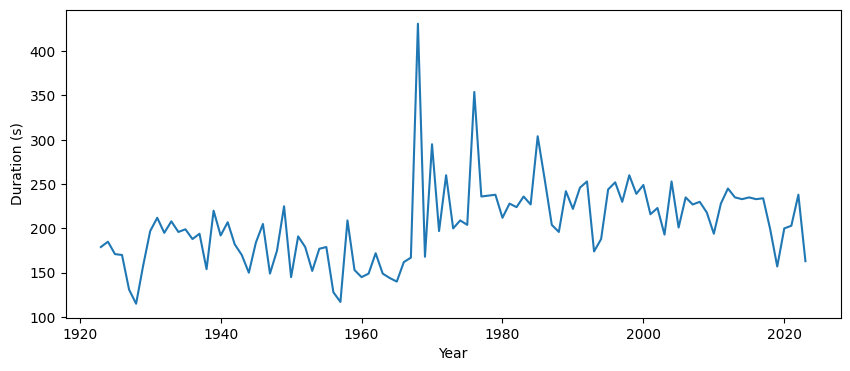

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(df['year'], df['total_seconds'])
plt.xlabel('Year')
plt.ylabel('Duration (s)')
plt.show()

### **Project extensions**


- What is the average duration of top songs prior to 1968? After 1968?



In [16]:
df.query('year < 1968')['total_seconds'].mean()

np.float64(172.64444444444445)

In [ ]:
df.query('year > 1968')['total_seconds'].mean()

np.float64(226.83636363636364)